## Random Forests (Regression)

A single **regression tree** (see `regression_tree.ipynb`) is easy to read but has a problem: it is **high variance**. Change the training data a little and the tree can look completely different. Deep trees happily *memorise noise* — they overfit.

A **random forest** fixes this by building **many** trees and averaging their predictions. Two tricks make the trees different from each other so their errors cancel out:

1. **Bagging (Bootstrap AGGregating)** — each tree is trained on a random *bootstrap sample* (draw N points with replacement) instead of the full dataset.
2. **Feature randomness** — at each split the tree may only consider a random subset of features.

Each individual tree is a weak, wiggly, overfit learner. But the **average of many de-correlated trees** is smooth and stable:

$$\hat{y}(x) = \frac{1}{B} \sum_{b=1}^{B} T_b(x)$$

where $T_b$ is the $b$-th tree and $B$ is the number of trees. Averaging keeps the low **bias** of trees while slashing their **variance** — that is the whole point.

### Tree vs forest — the trade-off

| | Single regression tree | Random forest |
|---|---|---|
| **Variance** | High — sensitive to small data changes | Low — averaging cancels noise |
| **Overfitting** | Prone to it (esp. deep trees) | Resistant |
| **Prediction shape** | Coarse staircase | Fine, smoother staircase |
| **Interpretability** | Easy — you can read the whole tree | Hard — hundreds of trees |
| **Cost** | Cheap | ~B× the work (but trees are parallel) |

**Takeaway:** a single tree is the right tool when you need to *explain* the decision. When you just want the *best prediction* and can spare the compute, a random forest almost always wins by trading a bit of interpretability for a large drop in variance.

Two knobs matter most for a forest: `n_estimators` (more trees = more stable, with diminishing returns) and `max_features` (how much feature randomness — lower values de-correlate the trees more).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

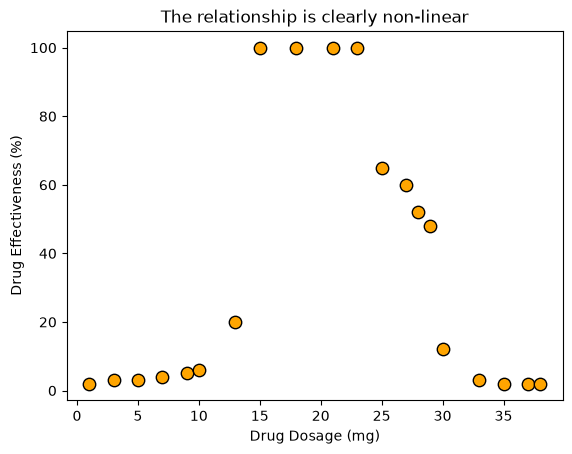

In [2]:
# Same drug dosage (mg) vs effectiveness (%) data as the regression tree notebook
dosage = np.array([
    1, 3, 5, 7, 9, 10, 13,          # low dose  -> barely works
    15, 18, 21, 23,                 # sweet spot -> ~100% effective
    25, 27, 28, 29,                 # a bit too much -> tapering off
    30, 33, 35, 37, 38              # high dose -> back to useless
]).reshape(-1, 1)

effectiveness = np.array([
    2, 3, 3, 4, 5, 6, 20,
    100, 100, 100, 100,
    65, 60, 52, 48,
    12, 3, 2, 2, 2
])

plt.scatter(dosage, effectiveness, color="orange", edgecolor="black", s=80)
plt.xlabel("Drug Dosage (mg)")
plt.ylabel("Drug Effectiveness (%)")
plt.title("The relationship is clearly non-linear")
plt.show()

### Fit both models

To make the contrast obvious we deliberately let a **single tree grow deep** (`max_depth=None`) so it overfits, and compare it against a **random forest** of 300 such trees. Because the forest *averages* many overfit trees, its prediction comes out far smoother even though each tree inside it is just as wiggly as the lone tree.

In [3]:
# A single, deep (overfitting) regression tree
tree = DecisionTreeRegressor(random_state=0)
tree.fit(dosage, effectiveness)

# A random forest: 300 trees, each on a bootstrap sample
forest = RandomForestRegressor(n_estimators=300, random_state=0)
forest.fit(dosage, effectiveness)

# Predict across a smooth range of dosages
grid = np.linspace(0, 40, 500).reshape(-1, 1)
tree_preds = tree.predict(grid)
forest_preds = forest.predict(grid)

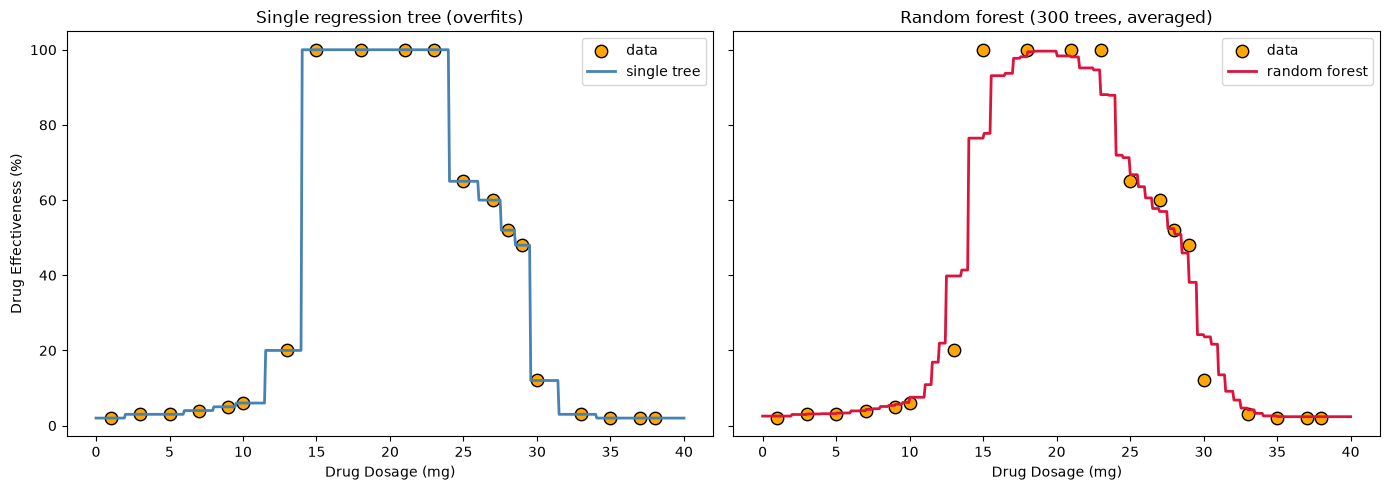

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].scatter(dosage, effectiveness, color="orange", edgecolor="black", s=80, label="data")
axes[0].plot(grid, tree_preds, color="steelblue", linewidth=2, label="single tree")
axes[0].set_title("Single regression tree (overfits)")
axes[0].set_xlabel("Drug Dosage (mg)")
axes[0].set_ylabel("Drug Effectiveness (%)")
axes[0].legend()

axes[1].scatter(dosage, effectiveness, color="orange", edgecolor="black", s=80, label="data")
axes[1].plot(grid, forest_preds, color="crimson", linewidth=2, label="random forest")
axes[1].set_title("Random forest (300 trees, averaged)")
axes[1].set_xlabel("Drug Dosage (mg)")
axes[1].legend()

plt.tight_layout()
plt.show()

The single tree's line hits **every point exactly** — one tiny step per data point. That is textbook overfitting: it has learned the noise, not the trend.

The random forest is a **finer, gentler staircase**. Each of its 300 trees saw a different bootstrap sample and split in a slightly different place, so averaging them smooths out the individual over-reactions while keeping the overall shape.

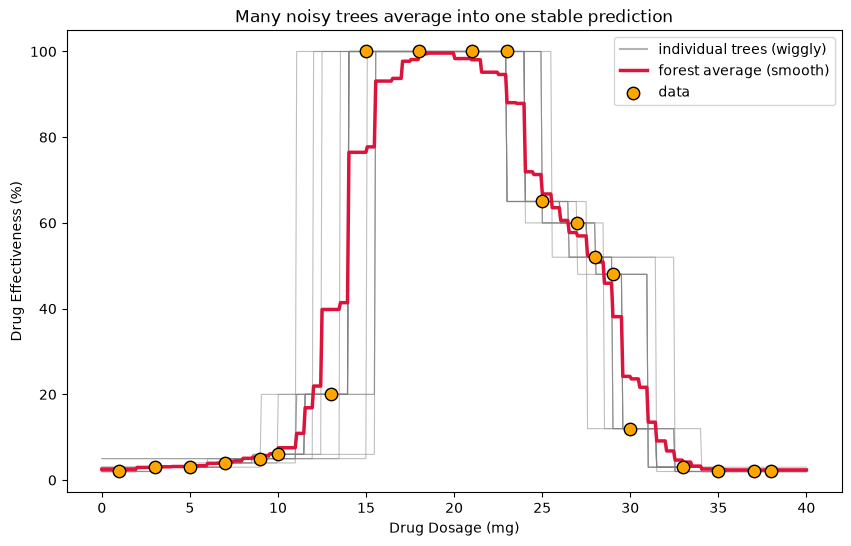

In [5]:
# Overlay a handful of individual trees from the forest to see the averaging in action
plt.figure(figsize=(10, 6))
for est in forest.estimators_[:15]:
    plt.plot(grid, est.predict(grid), color="grey", linewidth=0.8, alpha=0.5)
plt.plot([], [], color="grey", alpha=0.6, label="individual trees (wiggly)")
plt.plot(grid, forest_preds, color="crimson", linewidth=2.5, label="forest average (smooth)")
plt.scatter(dosage, effectiveness, color="orange", edgecolor="black", s=80, zorder=5, label="data")
plt.xlabel("Drug Dosage (mg)")
plt.ylabel("Drug Effectiveness (%)")
plt.title("Many noisy trees average into one stable prediction")
plt.legend()
plt.show()

### Which one generalises better?

A prediction that hugs the training data is not the same as a *good* prediction. To judge generalisation we use **cross-validation**: repeatedly hold out part of the data, fit on the rest, and score on the held-out part. Lower mean-squared-error is better.

In [6]:
# 5-fold cross-validation, scored by mean squared error (lower is better)
tree_cv = -cross_val_score(DecisionTreeRegressor(random_state=0),
                           dosage, effectiveness, cv=5,
                           scoring="neg_mean_squared_error")
forest_cv = -cross_val_score(RandomForestRegressor(n_estimators=300, random_state=0),
                             dosage, effectiveness, cv=5,
                             scoring="neg_mean_squared_error")

print(f"Single tree    | CV mean squared error: {tree_cv.mean():7.1f}")
print(f"Random forest  | CV mean squared error: {forest_cv.mean():7.1f}")
print()
print("Predictions for a few new dosages:")
print(f"{'dosage':>8} | {'tree':>8} | {'forest':>8}")
for d in [8, 20, 26, 34]:
    t = tree.predict([[d]])[0]
    f = forest.predict([[d]])[0]
    print(f"{d:>6} mg | {t:>6.1f}% | {f:>6.1f}%")

Single tree    | CV mean squared error:   449.6
Random forest  | CV mean squared error:   426.7

Predictions for a few new dosages:
  dosage |     tree |   forest
     8 mg |    4.0% |    4.5%
    20 mg |  100.0% |   99.6%
    26 mg |   65.0% |   63.6%
    34 mg |    3.0% |    3.3%
